In [1]:
from google.colab import files
files.upload()

Saving synthetic_financial_data.csv to synthetic_financial_data.csv


{'synthetic_financial_data.csv': b'transaction_id,customer_id,merchant_id,amount,transaction_time,is_fraudulent,card_type,location,purchase_category,customer_age,transaction_description\n1,1082,2027,5758.59,2023-01-01 00:00:00,0,MasterCard,City-30,Gas Station,43,Purchase at Merchant-2027\n2,1015,2053,1901.56,2023-01-01 00:00:01,1,Visa,City-47,Online Shopping,61,Purchase at Merchant-2053\n3,1004,2035,1248.86,2023-01-01 00:00:02,1,MasterCard,City-6,Gas Station,57,Purchase at Merchant-2035\n4,1095,2037,7619.05,2023-01-01 00:00:03,1,Discover,City-6,Travel,59,Purchase at Merchant-2037\n5,1036,2083,1890.1,2023-01-01 00:00:04,1,MasterCard,City-34,Retail,36,Purchase at Merchant-2083\n6,1032,2021,8487.68,2023-01-01 00:00:05,1,American Express,City-1,Gas Station,43,Purchase at Merchant-2021\n7,1029,2033,7565.3,2023-01-01 00:00:06,1,Visa,City-7,Online Shopping,19,Purchase at Merchant-2033\n8,1018,2088,2284.88,2023-01-01 00:00:07,0,American Express,City-46,Travel,40,Purchase at Merchant-2088\n9,10

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')
import shap
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.neighbors import NearestNeighbors

In [3]:
df = pd.read_csv("synthetic_financial_data.csv")

In [4]:
top_15_cities = [
    'New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix',
    'Philadelphia', 'San Antonio', 'San Diego', 'Dallas', 'Austin',
    'Jacksonville', 'San Jose', 'Fort Worth', 'Columbus', 'Charlotte'
]
unique_city_codes = sorted(df['location'].unique())
repeated_cities = np.resize(top_15_cities, len(unique_city_codes))
city_map = dict(zip(unique_city_codes, repeated_cities))
df['city_name'] = df['location'].map(city_map)

In [5]:
city_coordinates = {
    'New York': (40.7128, -74.0060),
    'Los Angeles': (34.0522, -118.2437),
    'Chicago': (41.8781, -87.6298),
    'Houston': (29.7604, -95.3698),
    'Phoenix': (33.4484, -112.0740),
    'Philadelphia': (39.9526, -75.1652),
    'San Antonio': (29.4241, -98.4936),
    'San Diego': (32.7157, -117.1611),
    'Dallas': (32.7767, -96.7970),
    'Austin': (30.2672, -97.7431),
    'Jacksonville': (30.3322, -81.6557),
    'San Jose': (37.3382, -121.8863),
    'Fort Worth': (32.7555, -97.3308),
    'Columbus': (39.9612, -82.9988),
    'Charlotte': (35.2271, -80.8431)
}

In [6]:
df['city_name'].unique()

array([np.str_('Dallas'), np.str_('San Jose'), np.str_('Los Angeles'),
       np.str_('Fort Worth'), np.str_('New York'), np.str_('Chicago'),
       np.str_('Jacksonville'), np.str_('Austin'), np.str_('San Antonio'),
       np.str_('Phoenix'), np.str_('Houston'), np.str_('Columbus'),
       np.str_('Charlotte'), np.str_('Philadelphia'),
       np.str_('San Diego')], dtype=object)

In [7]:
df[['latitude', 'longitude']] = df['city_name'].map(city_coordinates).apply(pd.Series)

In [8]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 transaction_id             0
customer_id                0
merchant_id                0
amount                     0
transaction_time           0
is_fraudulent              0
card_type                  0
location                   0
purchase_category          0
customer_age               0
transaction_description    0
city_name                  0
latitude                   0
longitude                  0
dtype: int64


In [9]:
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city_name'])


In [10]:
coords = df[['latitude', 'longitude']]
db = DBSCAN(eps=0.5, min_samples=5).fit(coords)
df['cluster_label'] = db.labels_


In [11]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df = df.sort_values(['customer_id', 'transaction_time'])
df['transaction_gap'] = df.groupby('customer_id')['transaction_time'].diff().dt.total_seconds()
df['transaction_gap'] = df['transaction_gap'].fillna(0)


In [14]:
feature_cols = ['amount', 'transaction_time', 'city_encoded', 'cluster_label', 'transaction_gap']
target_col = 'is_fraudulent'

df_model = df[feature_cols + [target_col]].dropna()

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_cols   = X_train.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
cat_cols  = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols  = [c for c in X_train.columns if c not in dt_cols + cat_cols]

def make_time_feats(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for c in df.columns:
        out[c + "_hour"] = df[c].dt.hour
        out[c + "_dow"]  = df[c].dt.dayofweek
        out[c + "_mon"]  = df[c].dt.month
        out[c + "_is_weekend"] = (df[c].dt.dayofweek >= 5).astype(int)
    return out

time_feat_tf = FunctionTransformer(make_time_feats, validate=False)

pre = ColumnTransformer(
    transformers=[
        ("time", time_feat_tf, dt_cols),
        ("cat",  OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num",  "passthrough", num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

clf = Pipeline(steps=[
    ("pre", pre),
    ("xgb", XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42
    ))
])

clf.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('time',
                                                  FunctionTransformer(func=<function make_time_feats at 0x7d9fda5be2a0>),
                                                  ['transaction_time']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  []),
                                                 ('num', 'passthrough',
                                                  ['amount', 'city_encoded',
                                                   'cluster_label',
                                                   'transaction_gap'])],
                                   verbose_feature_names_out=False)),
                ('xgb',
                 XGBClassifier(base_scor...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

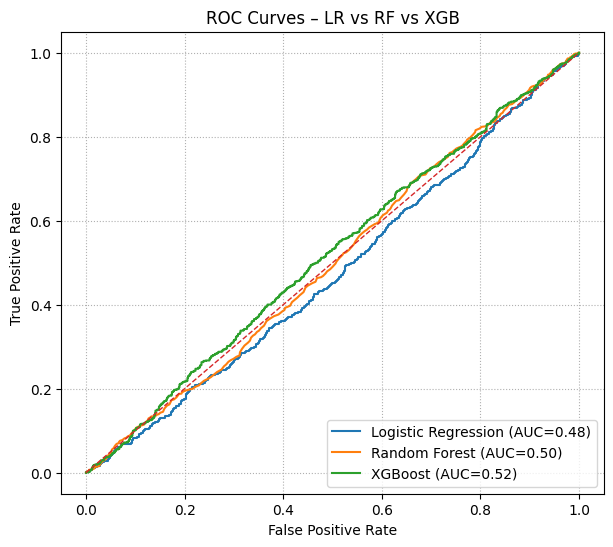


Logistic Regression — ROC-AUC: 0.476
              precision    recall  f1-score   support

           0      0.477     0.300     0.369       986
           1      0.500     0.680     0.576      1014

    accuracy                          0.493      2000
   macro avg      0.489     0.490     0.473      2000
weighted avg      0.489     0.493     0.474      2000


Random Forest — ROC-AUC: 0.501
              precision    recall  f1-score   support

           0      0.491     0.488     0.490       986
           1      0.505     0.509     0.507      1014

    accuracy                          0.498      2000
   macro avg      0.498     0.498     0.498      2000
weighted avg      0.498     0.498     0.498      2000


XGBoost — ROC-AUC: 0.517
              precision    recall  f1-score   support

           0      0.510     0.493     0.501       986
           1      0.522     0.539     0.531      1014

    accuracy                          0.516      2000
   macro avg      0.516     0.51

In [28]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


dt_cols  = X_train.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in dt_cols + cat_cols]


def make_time_feats(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for c in df.columns:
        out[f"{c}_hour"] = df[c].dt.hour
        out[f"{c}_dow"]  = df[c].dt.dayofweek
        out[f"{c}_mon"]  = df[c].dt.month
        out[f"{c}_wknd"] = (df[c].dt.dayofweek >= 5).astype(int)

    return out

from sklearn.preprocessing import FunctionTransformer
time_tf = FunctionTransformer(make_time_feats, validate=False)
pre = ColumnTransformer(
    transformers=[
        ("time", time_tf, dt_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

lr = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

rf = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))
])

xgb = Pipeline([
    ("pre", pre),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42
    ))
])

models = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}

plt.figure(figsize=(7, 6))
summary = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)
    summary.append((name, auc_val))
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.2f})")

plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.title("ROC Curves – LR vs RF vs XGB")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":")
plt.show()

for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    auc_val = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    print(f"\n{name} — ROC-AUC: {auc_val:.3f}")
    print(classification_report(y_test, y_pred, digits=3))


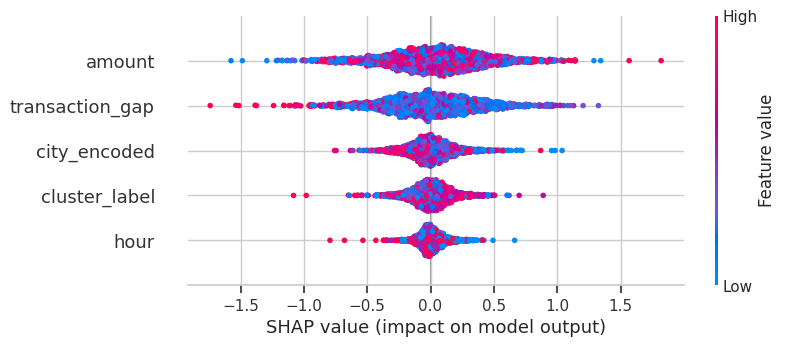

In [ ]:
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


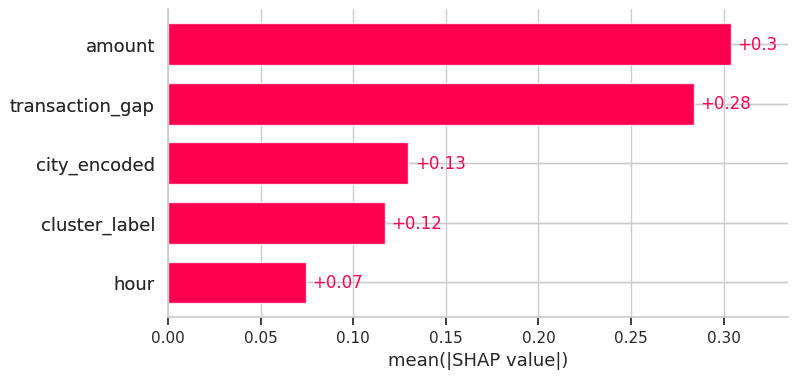

In [ ]:
shap.plots.bar(shap_values, max_display=10)

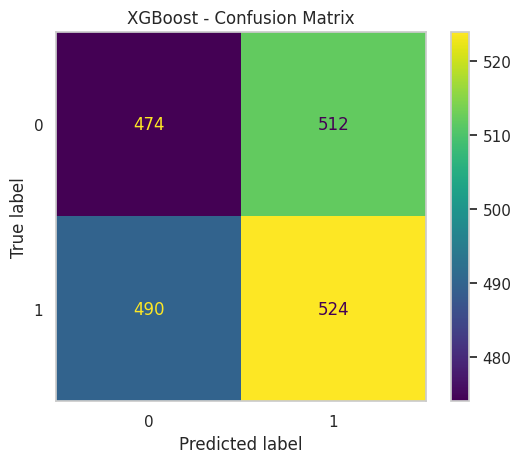

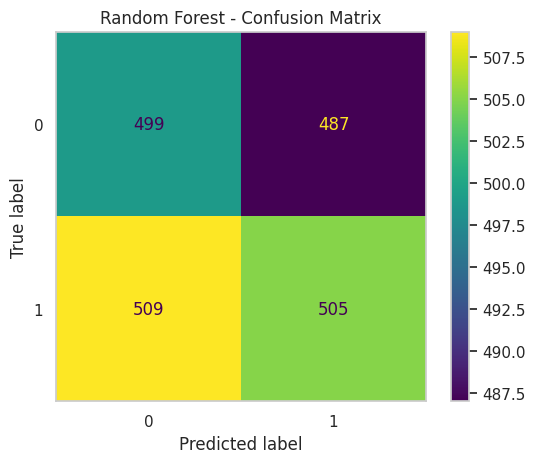

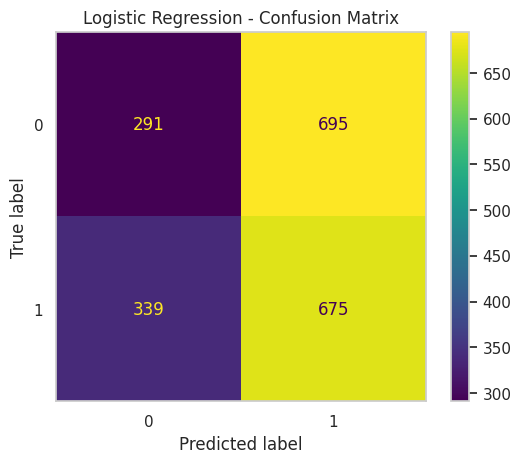

In [ ]:
models = {
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model
}

for name, model in models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} - Confusion Matrix')
    plt.grid(False)
    plt.show()


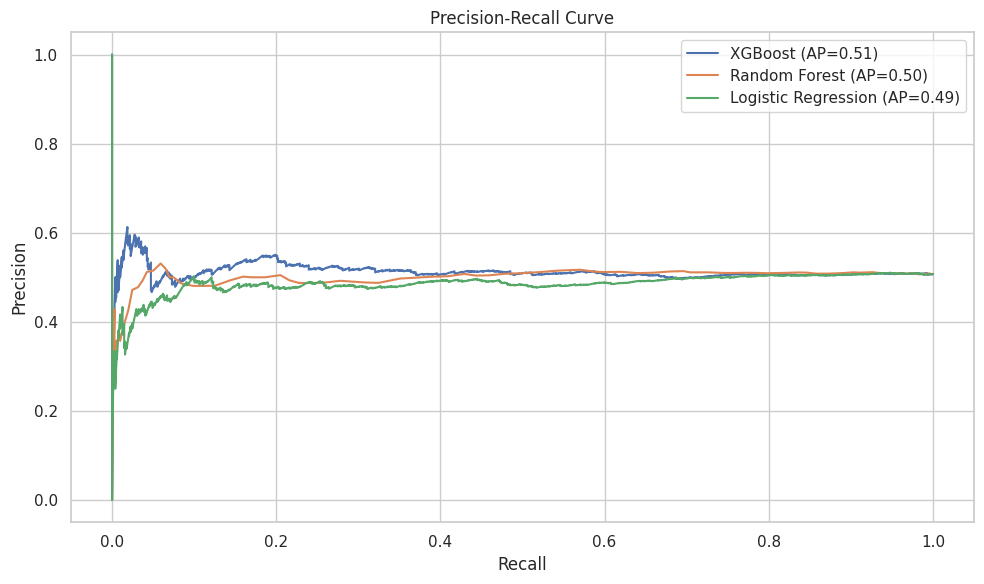

In [ ]:
plt.figure(figsize=(10,6))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
class ST_DBSCAN:
    def __init__(self, eps1, eps2, min_samples):
        self.eps1 = eps1
        self.eps2 = eps2
        self.min_samples = min_samples

    def fit_predict(self, X):
        spatial = X[:, :2]
        temporal = X[:, 2]

        n = X.shape[0]
        labels = np.full(n, -1)
        cluster_id = 0
        visited = np.zeros(n, dtype=bool)

        for i in range(n):
            if visited[i]:
                continue
            visited[i] = True

            neighbors = self._region_query(spatial, temporal, i)
            if len(neighbors) < self.min_samples:
                labels[i] = -1  # noise
            else:
                self._expand_cluster(spatial, temporal, labels, i, neighbors, cluster_id, visited)
                cluster_id += 1

        return labels

    def _region_query(self, spatial, temporal, idx):
        spatial_neighbors = NearestNeighbors(radius=self.eps1).fit(spatial).radius_neighbors([spatial[idx]], return_distance=False)[0]
        return [i for i in spatial_neighbors if abs(temporal[i] - temporal[idx]) <= self.eps2]

    def _expand_cluster(self, spatial, temporal, labels, idx, neighbors, cluster_id, visited):
        labels[idx] = cluster_id
        i = 0
        while i < len(neighbors):
            n_idx = neighbors[i]
            if not visited[n_idx]:
                visited[n_idx] = True
                next_neighbors = self._region_query(spatial, temporal, n_idx)
                if len(next_neighbors) >= self.min_samples:
                    neighbors.extend(next_neighbors)
            if labels[n_idx] == -1:
                labels[n_idx] = cluster_id
            i += 1


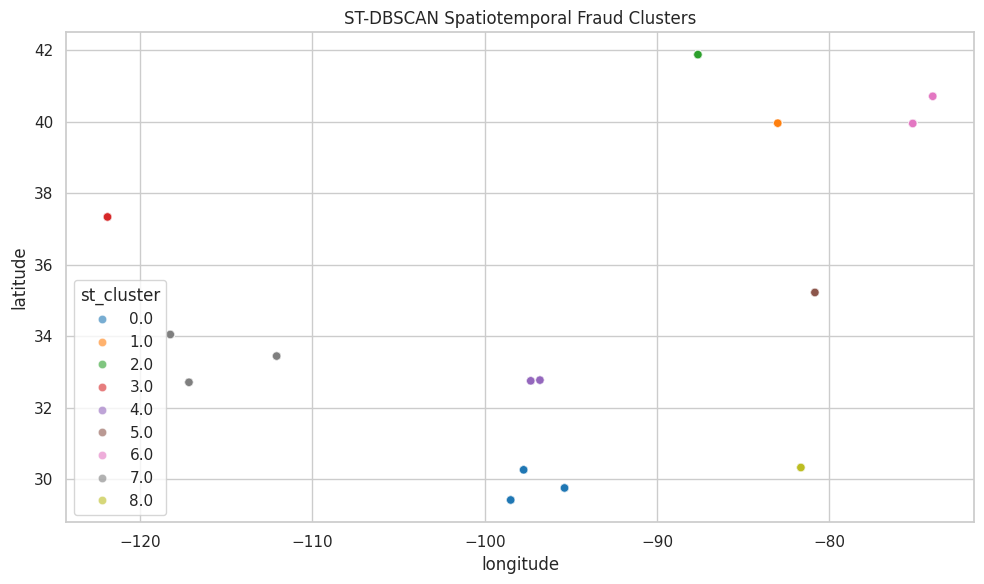

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='st_cluster', palette='tab10', alpha=0.6)
plt.title("ST-DBSCAN Spatiotemporal Fraud Clusters")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
cluster_stats = df.groupby('st_cluster')['is_fraudulent'].agg(['count', 'mean']).reset_index()
cluster_stats.rename(columns={'count': 'total_transactions', 'mean': 'fraud_rate'}, inplace=True)
cluster_stats.sort_values(by='fraud_rate', ascending=False)


,st_cluster,total_transactions,fraud_rate
6,6.0,1451,0.529290
4,4.0,1193,0.520536
2,2.0,838,0.517900
1,1.0,551,0.511797
0,0.0,1971,0.507864
3,3.0,587,0.504259
7,7.0,2204,0.495917
5,5.0,590,0.477966
8,8.0,615,0.473171
